In [1]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.1/12.8 MB 1.7 MB/s eta 0:00:08
      --------------------------------------- 0.2/12.8 MB 2.5 MB/s eta 0:00:06
     - -------------------------------------- 0.5/12.8 MB 3.7 MB/s eta 0:00:04
     -- ------------------------------------- 0.8/12.8 MB 4.5 MB/s eta 0:00:03
     --- ------------------------------------ 1.1/12.8 MB 5.1 MB/s eta 0:00:03
     ---- ----------------------------------- 1.4/12.8 MB 5.3 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 5.6 MB/s eta 0:00:02
     ------ --------------------------------- 2.1/12.8 MB 5.7 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 5.9 MB/s eta 0:00:02
     -------- ------------------------------- 2.8/12.8 MB 5.9 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.8 MB 6.0 MB/s eta 0:00:02
     ---------- ----------------------------- 3.4/12.8 MB 6

In [46]:


import pandas as pd
import numpy as np
import re
import nltk
import spacy

from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('stopwords')

# Load spaCy model
# Run once before if needed:
# !pip install spacy
# !python -m spacy download en_core_web_sm6

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))


# =====================================
# Load datasets
# =====================================

pandas_prs = pd.read_csv("prs_pandas.csv")
pandas_reviews = pd.read_csv("prs_reviews_pandas.csv")

modin_prs = pd.read_csv("prs_modin.csv")
modin_reviews = pd.read_csv("prs_reviews_modin.csv")


# =====================================
# Handle missing values
# =====================================

for df in [pandas_prs,
           pandas_reviews,
           modin_prs,
           modin_reviews]:

    for col in ["pr_title",
                "body",
                "review_text"]:

        if col in df.columns:

            df[col] = df[col].fillna("")


# =====================================
# Remove duplicates
# =====================================

pandas_prs.drop_duplicates(inplace=True)
pandas_reviews.drop_duplicates(inplace=True)

modin_prs.drop_duplicates(inplace=True)
modin_reviews.drop_duplicates(inplace=True)


# =====================================
# Convert timestamps
# =====================================

date_columns = [
    "created_at",
    "merged_at",
    "reviewed_at"
]

for df in [pandas_prs,
           pandas_reviews,
           modin_prs,
           modin_reviews]:

    for col in date_columns:

        if col in df.columns:

            df[col] = pd.to_datetime(
                df[col],
                errors='coerce'
            )


# =====================================
# Merge datasets
# =====================================

pandas_data = pd.merge(
    pandas_prs,
    pandas_reviews,
    on=["pr_id", "pr_author"],
    how="left"
)

modin_data = pd.merge(
    modin_prs,
    modin_reviews,
    on=["pr_id", "pr_author"],
    how="left"
)


# =====================================
# Combine text fields safely
# =====================================

pandas_data["combined_text"] = (
    pandas_data["pr_title"].astype(str)
    + " "
    + pandas_data["body"].astype(str)
    + " "
    + pandas_data["review_text"].astype(str)
)

modin_data["combined_text"] = (
    modin_data["pr_title"].astype(str)
    + " "
    + modin_data["body"].astype(str)
    + " "
    + modin_data["review_text"].astype(str)
)


# =====================================
# Text cleaning function
# =====================================

def clean_text(text):

    text = str(text)

    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+",
        "",
        text
    )

    # Remove punctuation/numbers
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# Apply cleaning

pandas_data["clean_text"] = (
    pandas_data["combined_text"]
    .apply(clean_text)
)

modin_data["clean_text"] = (
    modin_data["combined_text"]
    .apply(clean_text)
)


# =====================================
# Lemmatization + stopword removal
# =====================================

def preprocess(text):

    doc = nlp(text)

    words = []

    for token in doc:

        if (
            token.text not in stop_words
            and len(token.text) > 2
            and not token.is_space
        ):

            words.append(
                token.lemma_
            )

    return " ".join(words)


pandas_data["processed_text"] = (
    pandas_data["clean_text"]
    .apply(preprocess)
)

modin_data["processed_text"] = (
    modin_data["clean_text"]
    .apply(preprocess)
)


# =====================================
# Feature Engineering
# =====================================

# Merge duration

pandas_data["merge_days"] = (
    pandas_data["merged_at"]
    -
    pandas_data["created_at"]
).dt.days

modin_data["merge_days"] = (
    modin_data["merged_at"]
    -
    modin_data["created_at"]
).dt.days


# Contributor interaction weights

interaction_pandas = (
    pandas_reviews
    .groupby(
        ["reviewed_by",
         "pr_author"]
    )
    .size()
    .reset_index(
        name="weight"
    )
)

interaction_modin = (
    modin_reviews
    .groupby(
        ["reviewed_by",
         "pr_author"]
    )
    .size()
    .reset_index(
        name="weight"
    )
)


# =====================================
# Save cleaned datasets
# =====================================

pandas_data.to_csv(
    "cleaned_pandas.csv",
    index=False
)

modin_data.to_csv(
    "cleaned_modin.csv",
    index=False
)


print("Preprocessing completed successfully")


# Preview

print("\nPandas dataset sample:")
print(
    pandas_data[
        ["processed_text"]
    ].head()
)

print("\nModin dataset sample:")
print(
    modin_data[
        ["processed_text"]
    ].head()
)

[nltk_data] Downloading package stopwords to C:\Users\Adnaan
[nltk_data]     Shahab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing completed successfully

Pandas dataset sample:
                                      processed_text
0  bug areaplot ymin baseline pin defeat unrelate...
1  enh support dtype complex complex read csv eng...
2  tst show actual ymin ymax test area lim flake ...
3  typ enable mypy check panda core dtype miss su...
4  typ enable mypy check panda core dtype miss su...

Modin dataset sample:
                                      processed_text
0  fix correct typo occur recieve fix typo across...
1                      update readme release version
2  test fix comparison caster test check backend ...
3  test fix comparison caster test check backend ...
4  fix exceed max cost available backend error ma...


In [47]:
# Basic information

print("Pandas shape:", pandas_data.shape)
print("Modin shape:", modin_data.shape)

print("\n")

print("Pandas missing values:")
print(pandas_data.isnull().sum())

print("\n")

print("Modin missing values:")
print(modin_data.isnull().sum())

print("\n")

print("Sample processed text:")
print(pandas_data["processed_text"].head(5))

Pandas shape: (1147, 15)
Modin shape: (2047, 15)


Pandas missing values:
pr_id               0
pr_title            0
pr_author           0
state               0
created_at          0
merged_at         233
body                0
reviewed_by       797
review_state      797
review_text       797
reviewed_at       797
combined_text       0
clean_text          0
processed_text      0
merge_days        233
dtype: int64


Modin missing values:
pr_id               0
pr_title            0
pr_author           0
state               0
created_at          0
merged_at         112
body                0
reviewed_by       721
review_state      721
review_text       721
reviewed_at       721
combined_text       0
clean_text          0
processed_text      0
merge_days        112
dtype: int64


Sample processed text:
0    bug areaplot ymin baseline pin defeat unrelate...
1    enh support dtype complex complex read csv eng...
2    tst show actual ymin ymax test area lim flake ...
3    typ enable mypy check

In [4]:
# Text length

pandas_data["text_length"] = (
    pandas_data["processed_text"]
    .apply(lambda x: len(str(x).split()))
)

modin_data["text_length"] = (
    modin_data["processed_text"]
    .apply(lambda x: len(str(x).split()))
)

print(
    pandas_data["text_length"].describe()
)

print(
    modin_data["text_length"].describe()
)

count    1147.000000
mean       88.445510
std        99.468717
min         1.000000
25%        44.000000
50%        72.000000
75%       109.000000
max      1856.000000
Name: text_length, dtype: float64
count    2047.000000
mean      122.690278
std        79.859137
min         2.000000
25%       101.000000
50%       105.000000
75%       122.000000
max      1331.000000
Name: text_length, dtype: float64


In [5]:
!pip install wordcloud

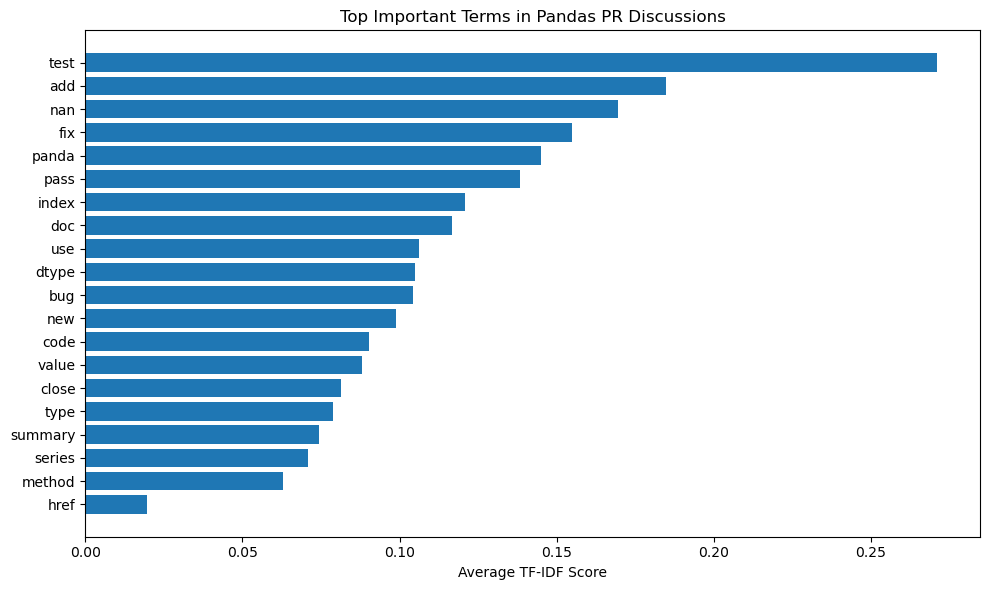

In [48]:
#Importing TF-IDF vectorizer to convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt


# Create TF-IDF vectorizer object
vectorizer = TfidfVectorizer(
    max_features=20,
    ngram_range=(1,2)   # include phrases like "bug fix"
)

# Transform processed text into a TF-IDF matrix
# Each row = one document
# Each column = one term/phrase
X = vectorizer.fit_transform(
    pandas_data["processed_text"]
)

# Calculate average TF-IDF score for each term across all documents
scores = X.mean(axis=0).A1

# Retrieve feature names (words/phrases)
terms = vectorizer.get_feature_names_out()

# Store terms and corresponding scores in a DataFrame
tfidf_df = pd.DataFrame({
    "Term": terms,
    "Score": scores
})


# Sort terms by score in ascending order
# This helps create a cleaner horizontal chart
tfidf_df = tfidf_df.sort_values(
    by="Score",
    ascending=True
)

# Set figure size for better readability
plt.figure(figsize=(10,6))

# Create horizontal bar chart
plt.barh(
    tfidf_df["Term"],
    tfidf_df["Score"]
)

# Add x-axis label
plt.xlabel("Average TF-IDF Score")

# Add chart title
plt.title("Top Important Terms in Pandas PR Discussions")

# Automatically adjust spacing
plt.tight_layout()

# Save figure as high-quality PNG image
plt.savefig(
    "pandas_tfidf.png",
    bbox_inches='tight',
    dpi=300
)

# Display chart
plt.show()

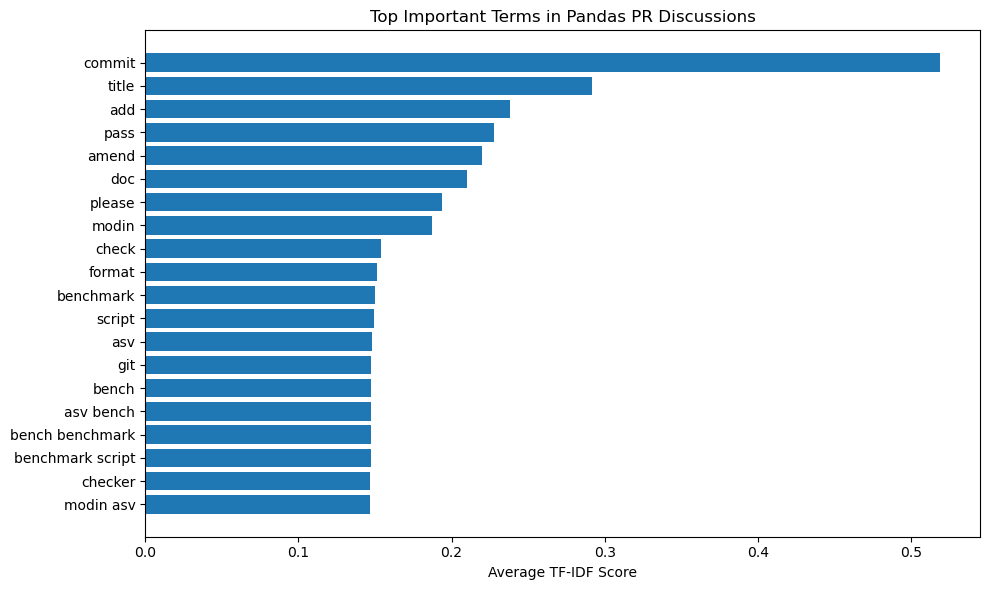

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Create TF-IDF vectorizer object
vectorizer = TfidfVectorizer(
    max_features=20,
    ngram_range=(1,2)   # include phrases like "bug fix"
)

# Transform processed text into a TF-IDF matrix
# Rows represent documents and columns represent terms
X = vectorizer.fit_transform(
    modin_data["processed_text"]
)


# Calculate average TF-IDF score for each term
scores = X.mean(axis=0).A1

# Retrieve feature names (terms and phrases)
terms = vectorizer.get_feature_names_out()


# Create DataFrame containing terms and scores
tfidf_df = pd.DataFrame({
    "Term": terms,
    "Score": scores
})

# Sort terms by importance score
# Ascending order helps readability in horizontal chart
tfidf_df = tfidf_df.sort_values(
    by="Score",
    ascending=True
)

# Create figure with specified size
plt.figure(figsize=(10,6))


# Create horizontal bar chart
plt.barh(
    tfidf_df["Term"],
    tfidf_df["Score"]
)


# Add x-axis label
plt.xlabel("Average TF-IDF Score")

# Add chart title
plt.title("Top Important Terms in Pandas PR Discussions")

# Automatically adjust plot spacing
plt.tight_layout()

# Save chart as high-quality image
plt.savefig(
    "modin_tfidf.png",
    bbox_inches='tight',
    dpi=300
)

# Display chart
plt.show()

Bot accounts removed from Pandas.
Pandas Network Statistics
--------------------------
Nodes: 31
Edges: 57
Density: 0.0613
Average degree: 3.68

Top Contributors
--------------------------
jbrockmendel 0.7333
rhshadrach 0.4333
jorisvandenbossche 0.4
mroeschke 0.3
Alvaro-Kothe 0.2
gautamvarmadatla 0.1667
Dr-Irv 0.1333
Vincent08199 0.1333
harrywzl 0.1333
Ashish-ml-eng 0.1
Mahajan-Sachin 0.1
Nikhil-jaiswal007 0.1
arzaan789 0.1
iabhi4 0.1
sun-0-set 0.1


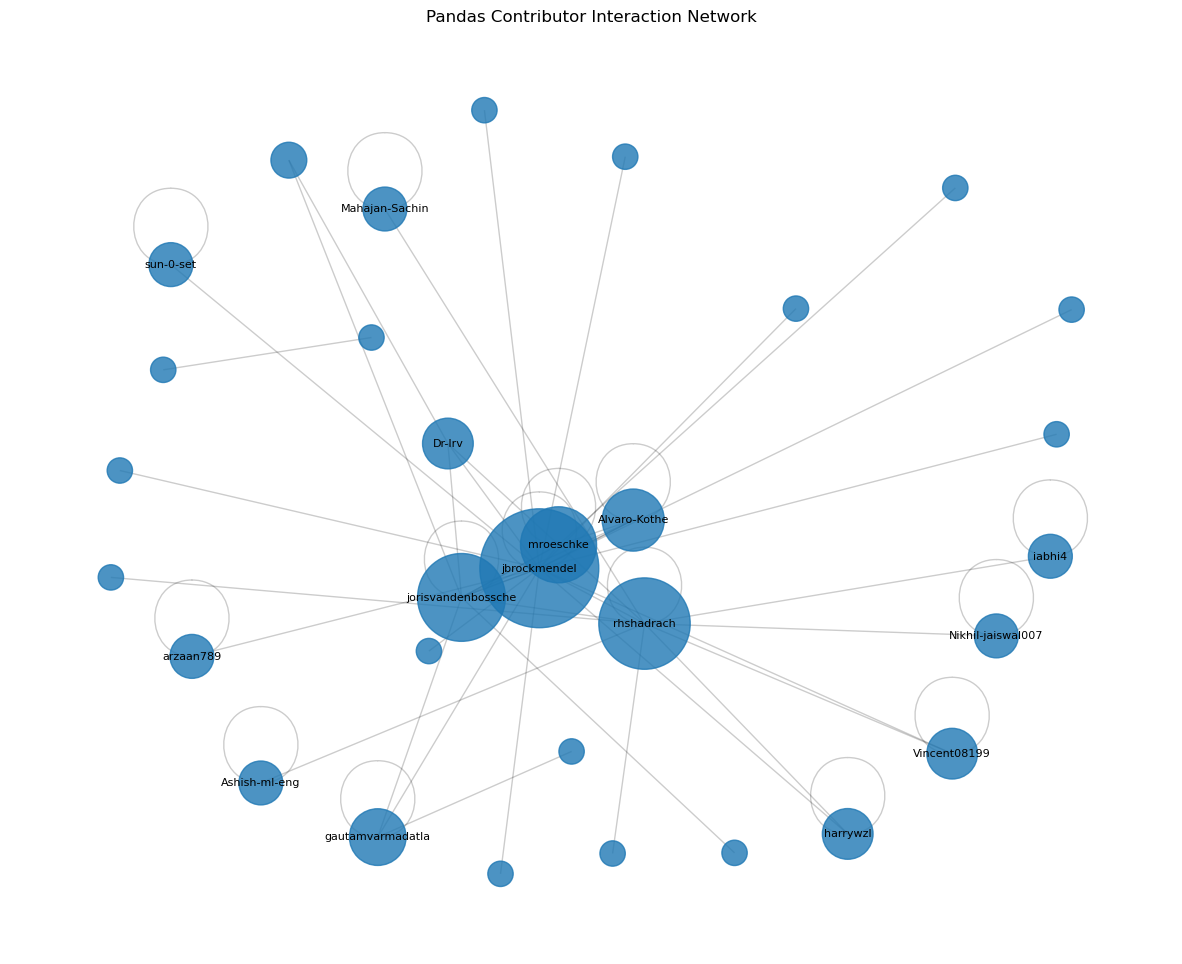

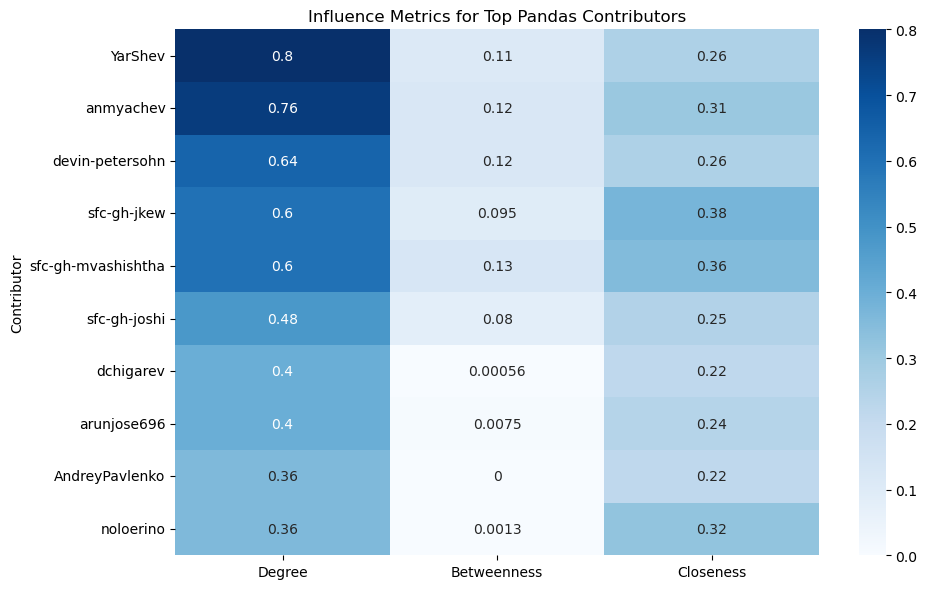

In [96]:
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# Pandas Contributor Network
# =========================

# Remove bot accounts from reviewer column
interaction_pandas = interaction_pandas[
    ~interaction_pandas["reviewed_by"]
    .str.contains(
        "bot",
        case=False,
        na=False
    )
]


# Remove bot accounts from PR author column
interaction_pandas = interaction_pandas[
    ~interaction_pandas["pr_author"]
    .str.contains(
        "bot",
        case=False,
        na=False
    )
]

# Display confirmation message
print("Bot accounts removed from Pandas.")


# Create directed graph from interaction data
# Nodes = contributors
# Edges = reviewer-author relationships
# Weight = interaction frequency
G_pandas = nx.from_pandas_edgelist(
    interaction_pandas,
    source='reviewed_by',
    target='pr_author',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

# =========================
# Network Statistics
# =========================

print("Pandas Network Statistics")
print("--------------------------")

# Display number of contributors
print("Nodes:", G_pandas.number_of_nodes())

# Display number of interactions
print("Edges:", G_pandas.number_of_edges())

# Calculate network density
# Density measures how connected the network is
print(
    "Density:",
    round(nx.density(G_pandas),4)
)

# Calculate average degree of contributors
print(
    "Average degree:",
    round(
        sum(dict(G_pandas.degree()).values())
        /
        G_pandas.number_of_nodes(),
        2
    )
)

# =========================
# Degree Centrality
# =========================
# Compute degree centrality
# Indicates contributor influence within network
centrality = nx.degree_centrality(
    G_pandas
)

# Top contributors
# Retrieve top 15 contributors by centrality
top_nodes = sorted(
    centrality,
    key=centrality.get,
    reverse=True
)[:15]

print("\nTop Contributors")
print("--------------------------")

# Display top contributor scores
for node in top_nodes:

    print(
        node,
        round(
            centrality[node],
            4
        )
    )

# =========================
# Labels
# =========================

labels = {
    node:node
    for node in top_nodes
}

# =========================
# Network Visualization
# =========================

plt.figure(figsize=(15,12))

# Generate node positions using spring layout
# Similar nodes tend to cluster together
pos = nx.spring_layout(
    G_pandas,
    k=0.5,
    seed=42
)

# Scale node sizes according to centrality
# Larger nodes represent more influential contributors
node_sizes = [

    centrality[node]*10000

    for node in G_pandas.nodes()
]

# Draw network nodes
nx.draw_networkx_nodes(
    G_pandas,
    pos,
    node_size=node_sizes,
    alpha=0.8
)


# Draw network edges
nx.draw_networkx_edges(
    G_pandas,
    pos,
    alpha=0.2,
    arrows=False
)

# Draw labels for top contributors only
nx.draw_networkx_labels(
    G_pandas,
    pos,
    labels,
    font_size=8
)

# Add chart title
plt.title(
    "Pandas Contributor Interaction Network"
)

# Remove axis display
plt.axis("off")

# Save network visualization
plt.savefig(
    "pandas_network_labels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Heatmap
plt.figure(figsize=(10,6))

# Generate heatmap for top contributor metrics
sns.heatmap(
    top10,
    annot=True,
    cmap="Blues"
)

plt.title(
    "Influence Metrics for Top Pandas Contributors"
)

plt.tight_layout()

plt.savefig(
    "pandas_influence_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Modin Network Statistics
--------------------------
Nodes: 26
Edges: 91
Density: 0.14
Average degree: 7.0

Top Contributors:
--------------------------
YarShev 0.8
anmyachev 0.76
devin-petersohn 0.64
sfc-gh-jkew 0.6
sfc-gh-mvashishtha 0.6
sfc-gh-joshi 0.48
dchigarev 0.4
arunjose696 0.4
AndreyPavlenko 0.36
noloerino 0.36
sfc-gh-dpetersohn 0.32
Retribution98 0.28
sfc-gh-vrpatel 0.2
data-makerman 0.16
vsreekanti 0.16


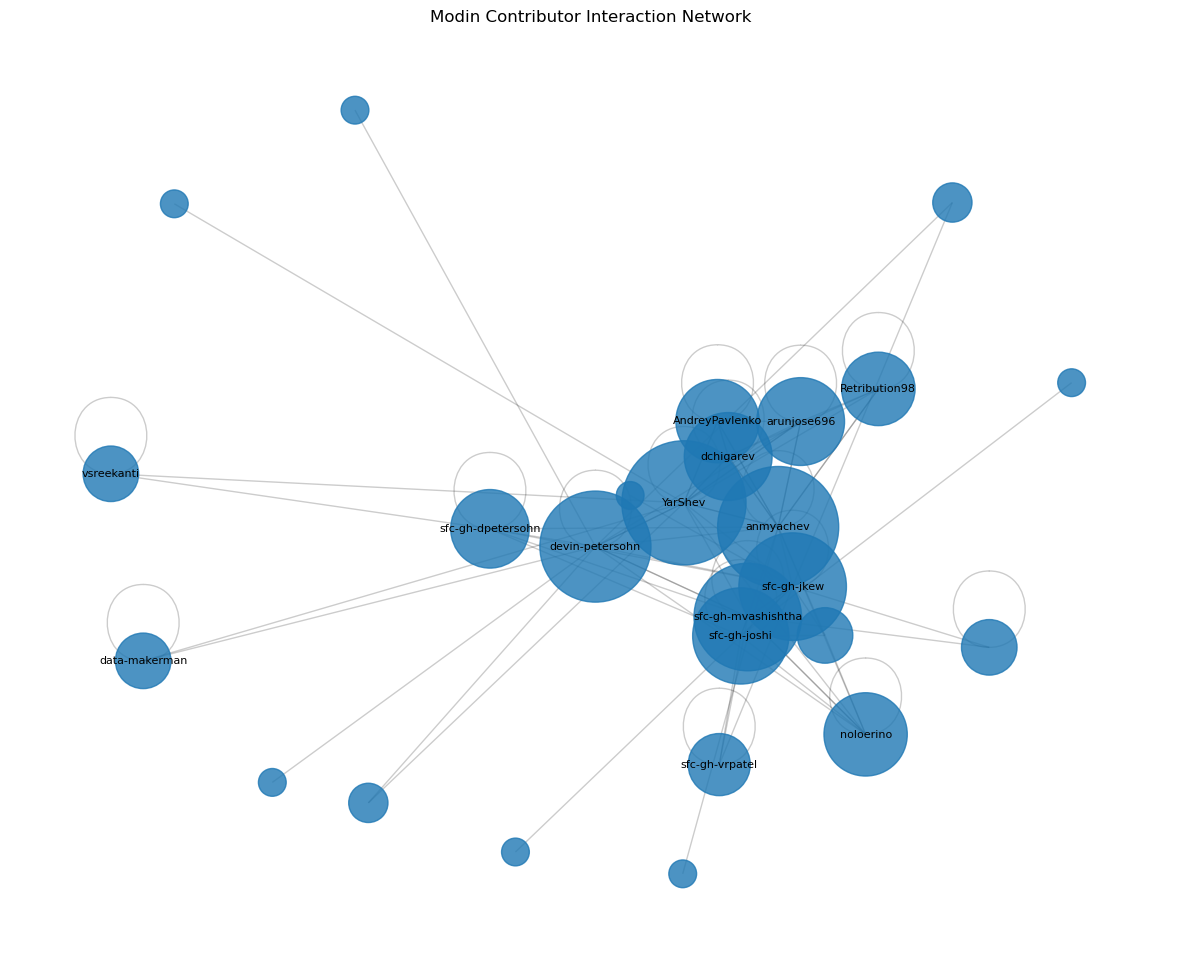

In [62]:
import networkx as nx
import matplotlib.pyplot as plt

#Removing bot accounts
interaction_modin = interaction_modin[
    ~interaction_modin["reviewed_by"]
    .str.contains(
        "bot",
        case=False,
        na=False
    )
]

interaction_modin = interaction_modin[
    ~interaction_modin["pr_author"]
    .str.contains(
        "bot",
        case=False,
        na=False
    )
]

# =========================
# Modin Network
# =========================

G_modin = nx.from_pandas_edgelist(
    interaction_modin,
    source='reviewed_by',
    target='pr_author',
    edge_attr='weight',
    create_using=nx.DiGraph()
)

# =========================
# Network Statistics
# =========================

print("Modin Network Statistics")
print("--------------------------")

print("Nodes:", G_modin.number_of_nodes())

print("Edges:", G_modin.number_of_edges())

print(
    "Density:",
    round(nx.density(G_modin),4)
)

print(
    "Average degree:",
    round(
        sum(dict(G_modin.degree()).values())
        /
        G_modin.number_of_nodes(),
        2
    )
)

# =========================
# Degree centrality
# =========================

centrality = nx.degree_centrality(
    G_modin
)

# Top contributors

top_nodes = sorted(
    centrality,
    key=centrality.get,
    reverse=True
)[:15]

print("\nTop Contributors:")
print("--------------------------")

for node in top_nodes:
    print(
        node,
        round(
            centrality[node],
            4
        )
    )

# =========================
# Labels dictionary
# =========================

labels = {
    node:node
    for node in top_nodes
}

# =========================
# Visualization
# =========================

plt.figure(figsize=(15,12))

pos = nx.spring_layout(
    G_modin,
    k=0.5,
    seed=42
)

# Node sizes according to importance

node_sizes = [

    centrality[node]*10000

    for node in G_modin.nodes()
]

nx.draw_networkx_nodes(
    G_modin,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_modin,
    pos,
    alpha=0.2,
    arrows=False
)

nx.draw_networkx_labels(
    G_modin,
    pos,
    labels,
    font_size=8
)

plt.title(
    "Modin Contributor Interaction Network"
)

plt.axis("off")

plt.savefig(
    "modin_network_labels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

           Contributor    Degree  Betweenness  Closeness
1         jbrockmendel  0.733333     0.108621   0.200000
27          rhshadrach  0.433333     0.042529   0.070588
4   jorisvandenbossche  0.400000     0.063218   0.150000
25           mroeschke  0.300000     0.052874   0.092308
0         Alvaro-Kothe  0.200000     0.000000   0.133333
7     gautamvarmadatla  0.166667     0.000000   0.164103
3               Dr-Irv  0.133333     0.000575   0.070588
14            harrywzl  0.133333     0.000000   0.136111
10        Vincent08199  0.133333     0.000000   0.136111
11           arzaan789  0.100000     0.000000   0.125641


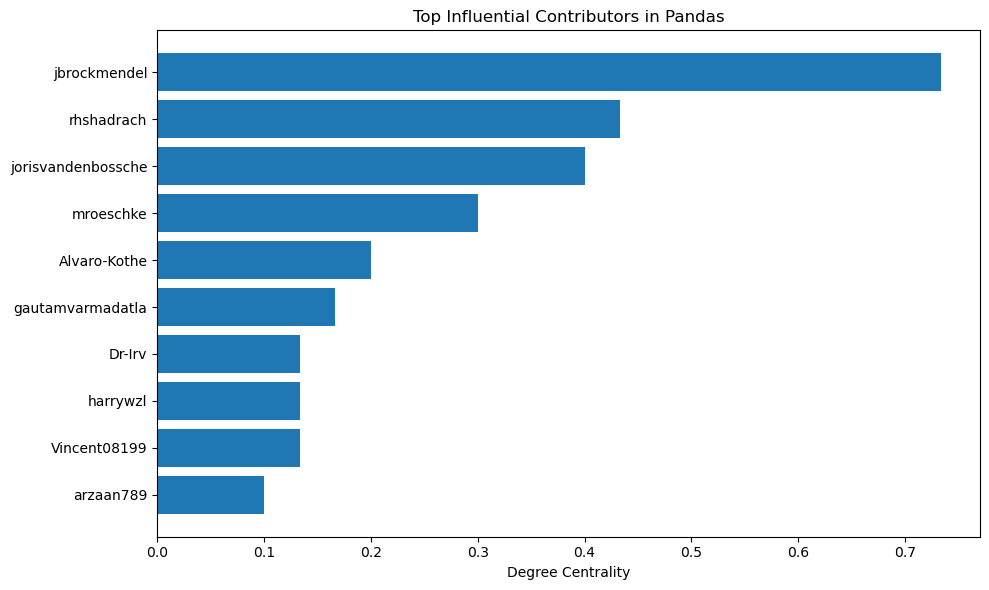

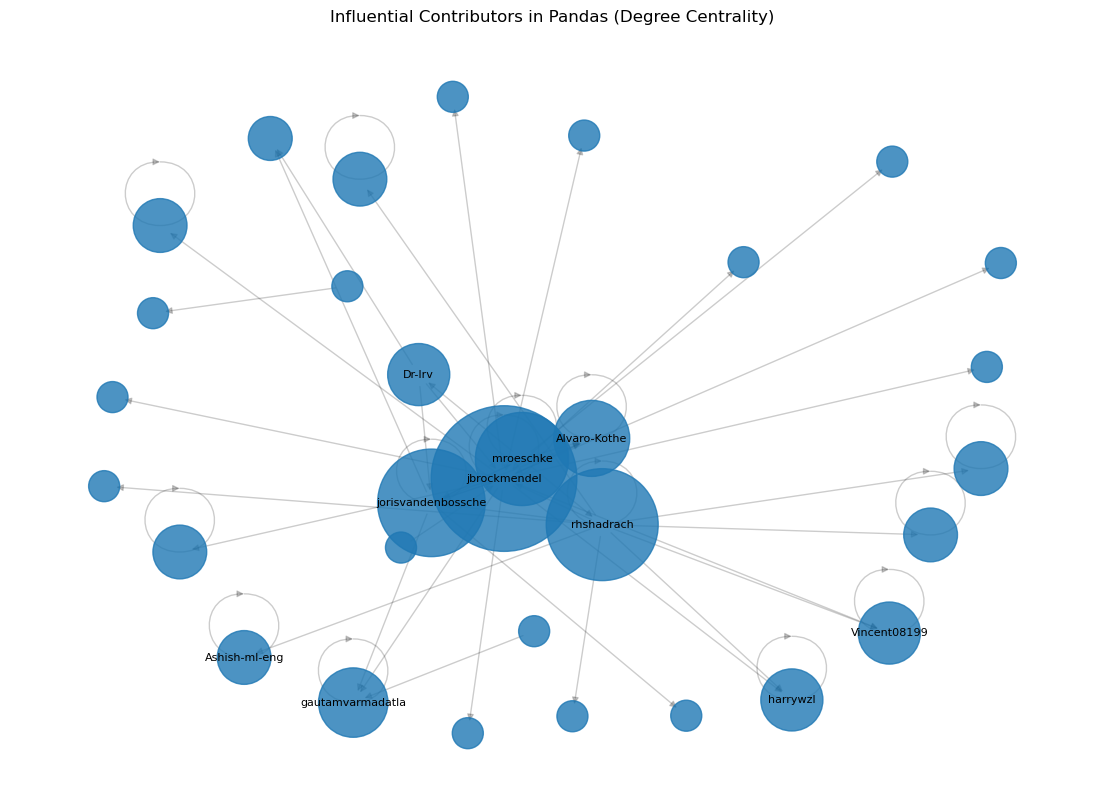

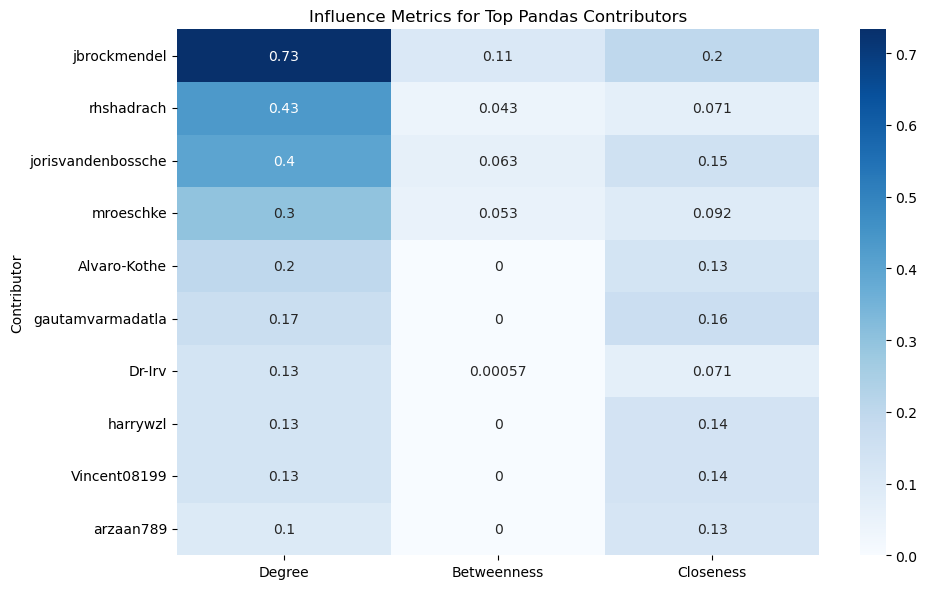

In [64]:
import pandas as pd
import networkx as nx

# =========================
# Centrality Measures
# =========================

degree = nx.degree_centrality(G_pandas)

betweenness = nx.betweenness_centrality(
    G_pandas
)

closeness = nx.closeness_centrality(
    G_pandas
)

# Combine results

influence_df = pd.DataFrame({

    "Contributor": degree.keys(),

    "Degree": degree.values(),

    "Betweenness": betweenness.values(),

    "Closeness": closeness.values()

})

# Top contributors

influence_df = influence_df.sort_values(
    by="Degree",
    ascending=False
)

print(
    influence_df.head(10)
)

import matplotlib.pyplot as plt

top10 = influence_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Contributor"],
    top10["Degree"]
)

plt.xlabel(
    "Degree Centrality"
)

plt.title(
    "Top Influential Contributors in Pandas"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "pandas_influence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

import matplotlib.pyplot as plt
import networkx as nx

degree = nx.degree_centrality(G_pandas)

plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G_pandas,
    k=0.5,
    seed=42
)

node_sizes = [
    degree[node] * 15000
    for node in G_pandas.nodes()
]

labels = {
    node: node
    for node in sorted(
        degree,
        key=degree.get,
        reverse=True
    )[:10]
}

nx.draw_networkx_nodes(
    G_pandas,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_pandas,
    pos,
    alpha=0.2
)

nx.draw_networkx_labels(
    G_pandas,
    pos,
    labels,
    font_size=8
)

plt.title(
    "Influential Contributors in Pandas (Degree Centrality)"
)

plt.axis("off")

plt.show()


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# Centrality measures
degree = nx.degree_centrality(G_pandas)
betweenness = nx.betweenness_centrality(G_pandas)
closeness = nx.closeness_centrality(G_pandas)

# Create dataframe
influence_df = pd.DataFrame({
    "Contributor": degree.keys(),
    "Degree": degree.values(),
    "Betweenness": betweenness.values(),
    "Closeness": closeness.values()
})

# Select top contributors
top10 = influence_df.sort_values(
    by="Degree",
    ascending=False
).head(10)

# Set contributor names as index
top10 = top10.set_index("Contributor")

# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    top10,
    annot=True,
    cmap="Blues"
)

plt.title(
    "Influence Metrics for Top Pandas Contributors"
)

plt.tight_layout()

plt.savefig(
    "pandas_influence_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Top Modin Contributors
----------------------
           Contributor  Degree  Betweenness  Closeness
1              YarShev    0.80     0.110556   0.260000
2            anmyachev    0.76     0.124028   0.307273
8      devin-petersohn    0.64     0.123889   0.260000
11         sfc-gh-jkew    0.60     0.095417   0.375556
12  sfc-gh-mvashishtha    0.60     0.130556   0.355789
20        sfc-gh-joshi    0.48     0.079583   0.250370
3            dchigarev    0.40     0.000556   0.218065
6          arunjose696    0.40     0.007500   0.241429
0       AndreyPavlenko    0.36     0.000000   0.218065
10           noloerino    0.36     0.001250   0.321905


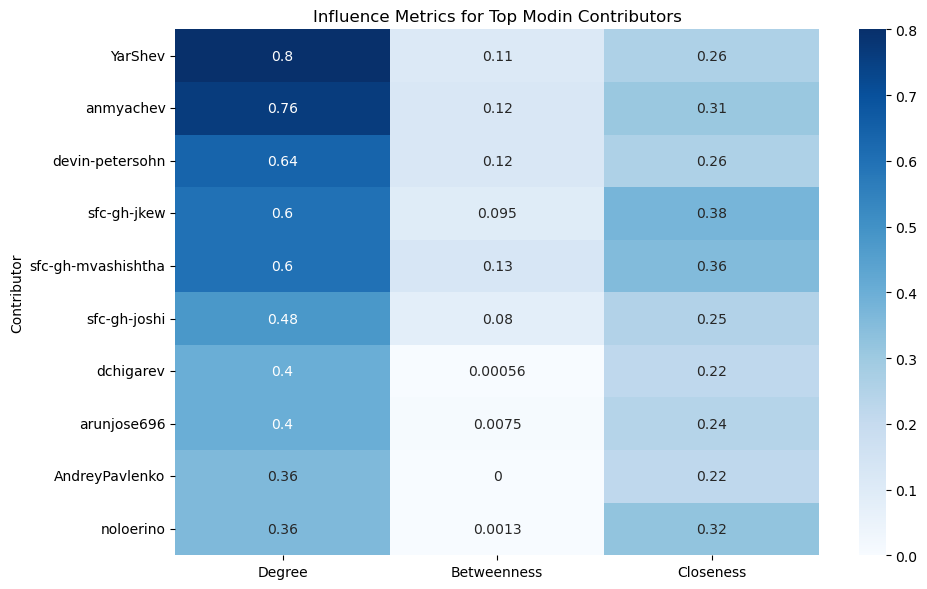

In [66]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Centrality Measures
# =========================

degree = nx.degree_centrality(G_modin)

betweenness = nx.betweenness_centrality(
    G_modin
)

closeness = nx.closeness_centrality(
    G_modin
)

# =========================
# Create influence dataframe
# =========================

influence_df = pd.DataFrame({

    "Contributor": degree.keys(),

    "Degree": degree.values(),

    "Betweenness": betweenness.values(),

    "Closeness": closeness.values()

})

# Sort contributors

influence_df = influence_df.sort_values(
    by="Degree",
    ascending=False
)

print("Top Modin Contributors")
print("----------------------")

print(
    influence_df.head(10)
)

# =========================
# Top 10 contributors
# =========================

top10 = influence_df.head(10)

top10 = top10.set_index(
    "Contributor"
)

# =========================
# Heatmap Visualization
# =========================

plt.figure(figsize=(10,6))

sns.heatmap(
    top10,
    annot=True,
    cmap="Blues"
)

plt.title(
    "Influence Metrics for Top Modin Contributors"
)

plt.tight_layout()

# Save image BEFORE show

plt.savefig(
    "modin_influence_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

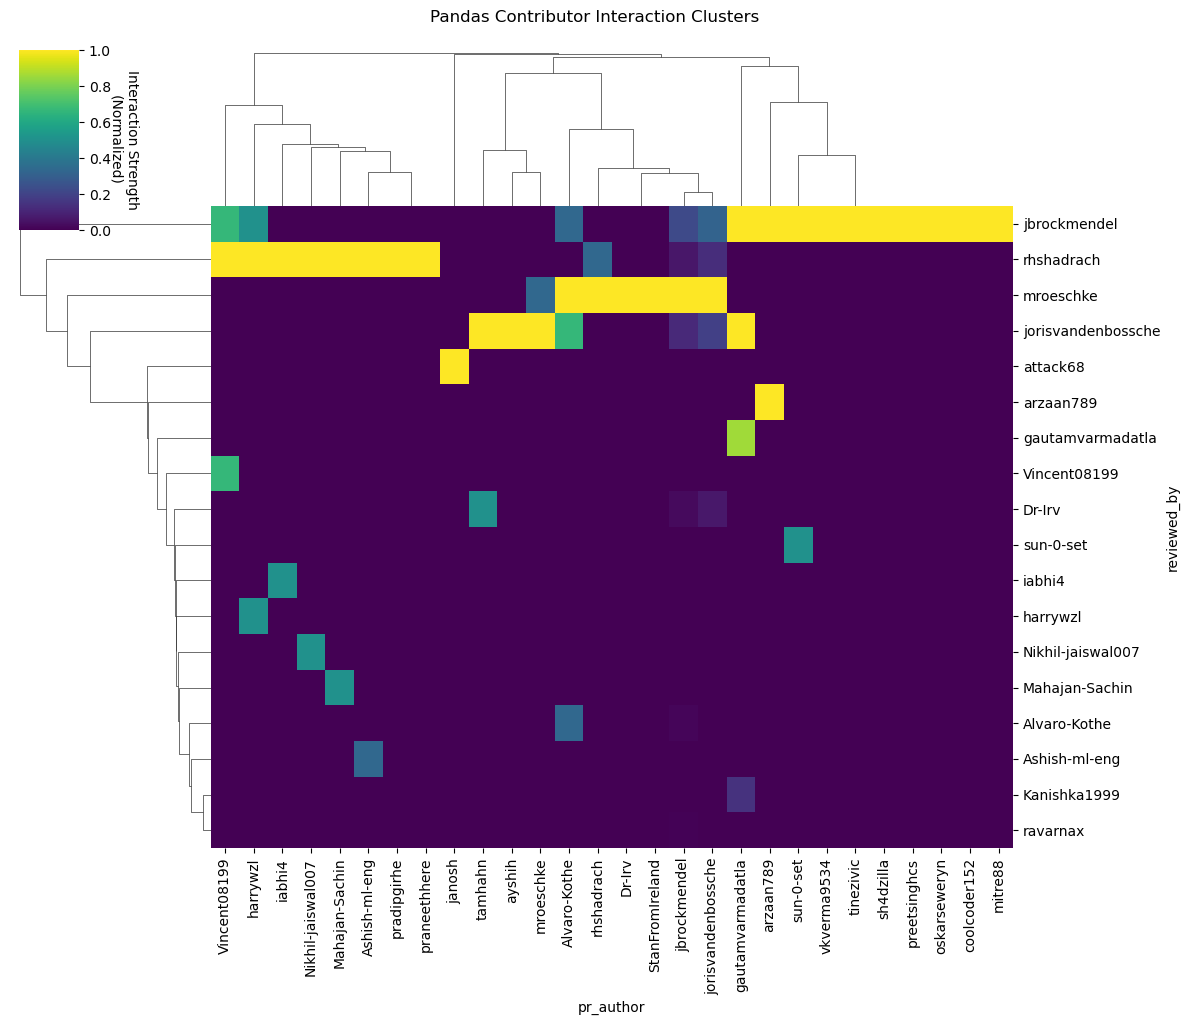

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create contributor interaction matrix
interaction_matrix = pd.pivot_table(
    interaction_pandas,
    values='weight',
    index='reviewed_by',
    columns='pr_author',
    fill_value=0
)

# Cluster map
g = sns.clustermap(
    interaction_matrix,
    cmap="viridis",
    figsize=(12,10),
    standard_scale=1,
    cbar_kws={
        "label":"Interaction Strength (Normalized)"
    }
)

plt.suptitle(
    "Pandas Contributor Interaction Clusters",
    y=1.02
)

# Improve colorbar title visibility
g.ax_cbar.set_ylabel(
    "Interaction Strength\n(Normalized)",
    rotation=270,
    labelpad=20
)

# Save figure
g.savefig(
    "pandas_cluster_map.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create contributor interaction matrix
interaction_matrix = pd.pivot_table(
    interaction_modin,
    values='weight',
    index='reviewed_by',
    columns='pr_author',
    fill_value=0
)

# Cluster map
g = sns.clustermap(
    interaction_matrix,
    cmap="viridis",
    figsize=(12,10),
    standard_scale=1,
    cbar_kws={
        "label":"Interaction Strength (Normalized)"
    }
)

plt.suptitle(
    "Modin Contributor Interaction Clusters",
    y=1.02
)

# Improve colorbar title visibility
g.ax_cbar.set_ylabel(
    "Interaction Strength\n(Normalized)",
    rotation=270,
    labelpad=20
)

# Save figure
g.savefig(
    "modin_cluster_map.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


Network Comparison
-----------------------
        Metric     Pandas  Modin
0        Nodes  31.000000  26.00
1        Edges  57.000000  91.00
2      Density   0.061290   0.14
3   Avg Degree   3.677419   7.00
4  Communities   6.000000   5.00


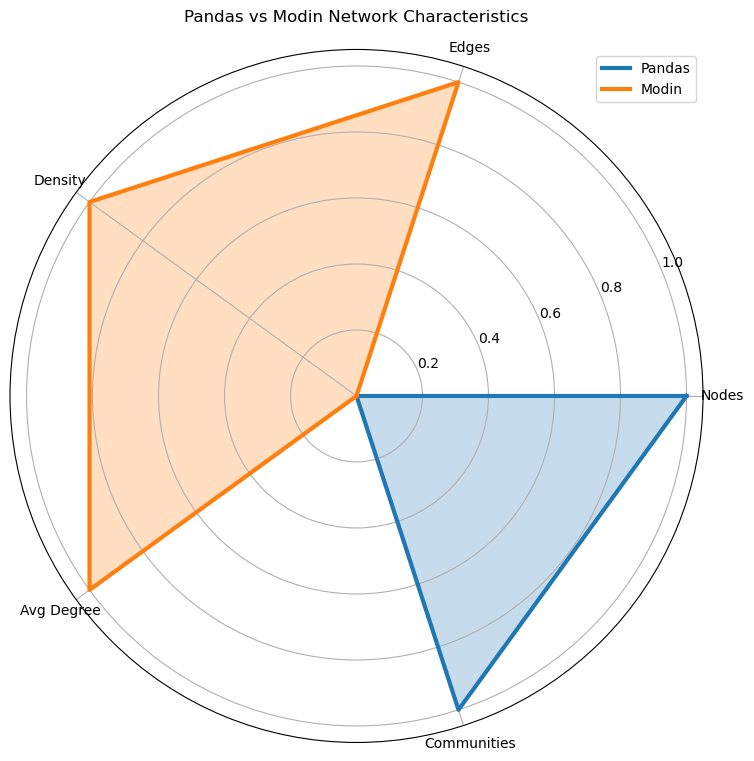

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from networkx.algorithms.community import greedy_modularity_communities
import networkx as nx

# =========================
# Calculate Pandas Metrics
# =========================

pandas_nodes = G_pandas.number_of_nodes()

pandas_edges = G_pandas.number_of_edges()

pandas_density = nx.density(G_pandas)

pandas_avg_degree = (
    sum(dict(G_pandas.degree()).values())
    /
    pandas_nodes
)

pandas_communities = len(
    list(
        greedy_modularity_communities(
            G_pandas.to_undirected()
        )
    )
)


# =========================
# Calculate Modin Metrics
# =========================

modin_nodes = G_modin.number_of_nodes()

modin_edges = G_modin.number_of_edges()

modin_density = nx.density(G_modin)

modin_avg_degree = (
    sum(dict(G_modin.degree()).values())
    /
    modin_nodes
)

modin_communities = len(
    list(
        greedy_modularity_communities(
            G_modin.to_undirected()
        )
    )
)

# =========================
# Create Comparison DataFrame
# =========================

comparison = pd.DataFrame({

    "Metric":[
        "Nodes",
        "Edges",
        "Density",
        "Avg Degree",
        "Communities"
    ],

    "Pandas":[
        pandas_nodes,
        pandas_edges,
        pandas_density,
        pandas_avg_degree,
        pandas_communities
    ],

    "Modin":[
        modin_nodes,
        modin_edges,
        modin_density,
        modin_avg_degree,
        modin_communities
    ]
})

print("\nNetwork Comparison")
print("-----------------------")
print(comparison)


# =========================
# Normalize values
# =========================

scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    comparison[["Pandas","Modin"]].T
)

pandas_values = scaled[0]
modin_values = scaled[1]


# Close radar loop

pandas_values = np.append(
    pandas_values,
    pandas_values[0]
)

modin_values = np.append(
    modin_values,
    modin_values[0]
)


labels = comparison["Metric"]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.append(
    angles,
    angles[0]
)


# =========================
# Radar Plot
# =========================

fig = plt.figure(
    figsize=(9,9)
)

ax = plt.subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    pandas_values,
    linewidth=3,
    label='Pandas'
)

ax.fill(
    angles,
    pandas_values,
    alpha=0.25
)

ax.plot(
    angles,
    modin_values,
    linewidth=3,
    label='Modin'
)

ax.fill(
    angles,
    modin_values,
    alpha=0.25
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels,
    fontsize=10
)

plt.title(
    "Pandas vs Modin Network Characteristics",
    pad=20
)

plt.legend(
    loc='upper right'
)

plt.savefig(
    "network_comparison_radar.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

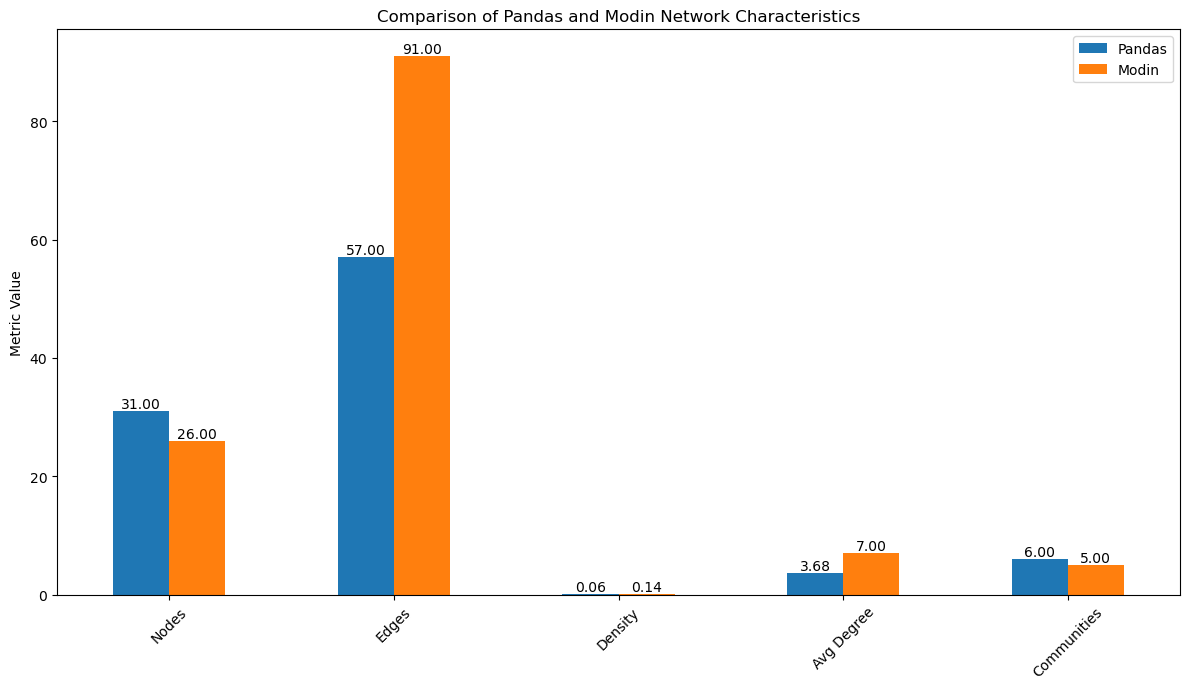

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
import networkx as nx
import numpy as np

# Calculate metrics automatically
metrics = {

    "Nodes":[
        G_pandas.number_of_nodes(),
        G_modin.number_of_nodes()
    ],

    "Edges":[
        G_pandas.number_of_edges(),
        G_modin.number_of_edges()
    ],

    "Density":[
        round(nx.density(G_pandas),4),
        round(nx.density(G_modin),4)
    ],

    "Avg Degree":[
        round(
            sum(dict(G_pandas.degree()).values())
            /
            G_pandas.number_of_nodes(),
            2
        ),

        round(
            sum(dict(G_modin.degree()).values())
            /
            G_modin.number_of_nodes(),
            2
        )
    ],

    "Communities":[
        len(
            list(
                greedy_modularity_communities(
                    G_pandas.to_undirected()
                )
            )
        ),

        len(
            list(
                greedy_modularity_communities(
                    G_modin.to_undirected()
                )
            )
        )
    ]
}

comparison = pd.DataFrame(
    metrics,
    index=["Pandas","Modin"]
)

ax = comparison.T.plot(
    kind='bar',
    figsize=(12,7)
)

plt.title(
    "Comparison of Pandas and Modin Network Characteristics"
)

plt.ylabel(
    "Metric Value"
)

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.tight_layout()

plt.savefig(
    "network_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import pandas as pd
import matplotlib.pyplot as plt

# ===================================
# Default + Custom Stopwords
# ===================================

custom_stopwords = {

    # GitHub / repository terms
    'https','http','com',
    'github','pr','commit',
    'title','pull',

    # Project names
    'pandas','modin',

    # HTML / markdown noise
    'href','html','li',
    'action','org',

    # Repository artifacts
    'dependabot',
    'codeql',
    'summary',
    'added',
    'closes',

    # Misc noise
    'py','claude',
    'new',
    'all'
}

all_stopwords = ENGLISH_STOP_WORDS.union(
    custom_stopwords
)


# ===================================
# Function for TF-IDF extraction
# ===================================

def get_tfidf_terms(text_data):

    vectorizer = TfidfVectorizer(
        stop_words=list(all_stopwords),
        max_features=15
    )

    X = vectorizer.fit_transform(
        text_data
    )

    scores = X.mean(axis=0).A1

    tfidf_df = pd.DataFrame({

        "Term":
        vectorizer.get_feature_names_out(),

        "Score":
        scores
    })

    return tfidf_df.sort_values(
        by="Score",
        ascending=True
    )


# ===================================
# Load text from cleaned columns
# ===================================

pandas_text = pandas_prs[
    "body"
].fillna("").astype(str)

modin_text = modin_prs[
    "body"
].fillna("").astype(str)


# ===================================
# Get TF-IDF data
# ===================================

pandas_tfidf = get_tfidf_terms(
    pandas_text
)

modin_tfidf = get_tfidf_terms(
    modin_text
)


# ===================================
# Side-by-side visualisation
# ===================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,8)
)

# Pandas graph
axes[0].barh(
    pandas_tfidf["Term"],
    pandas_tfidf["Score"]
)

axes[0].set_title(
    "Pandas TF-IDF Terms"
)

axes[0].set_xlabel(
    "TF-IDF Score"
)


# Modin graph
axes[1].barh(
    modin_tfidf["Term"],
    modin_tfidf["Score"]
)

axes[1].set_title(
    "Modin TF-IDF Terms"
)

axes[1].set_xlabel(
    "TF-IDF Score"
)


plt.suptitle(
    "Comparison of Important Discussion Terms in Pandas and Modin",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "tfidf_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

[nltk_data] Downloading package vader_lexicon to C:\Users\Adnaan
[nltk_data]     Shahab\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


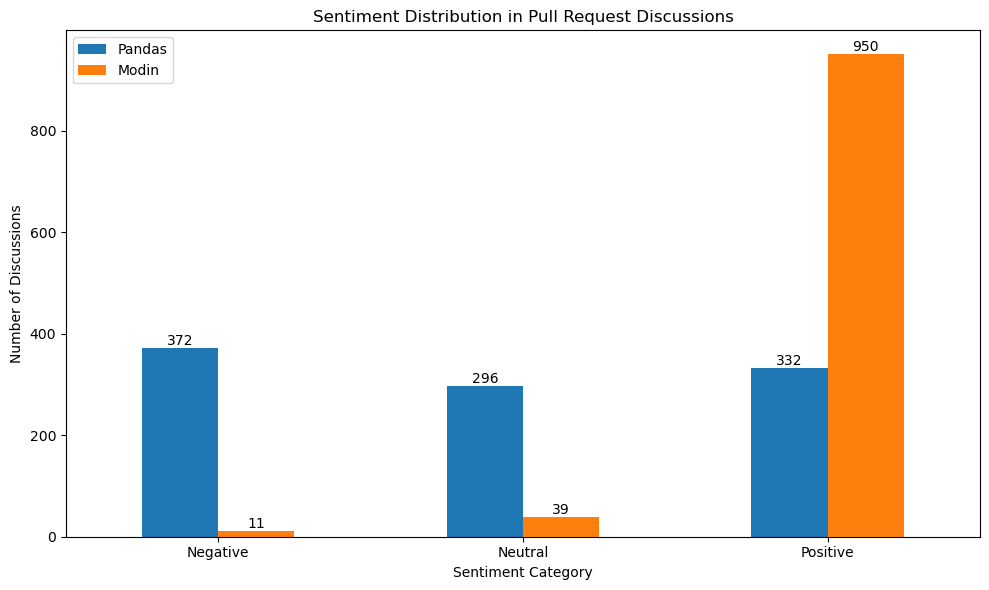

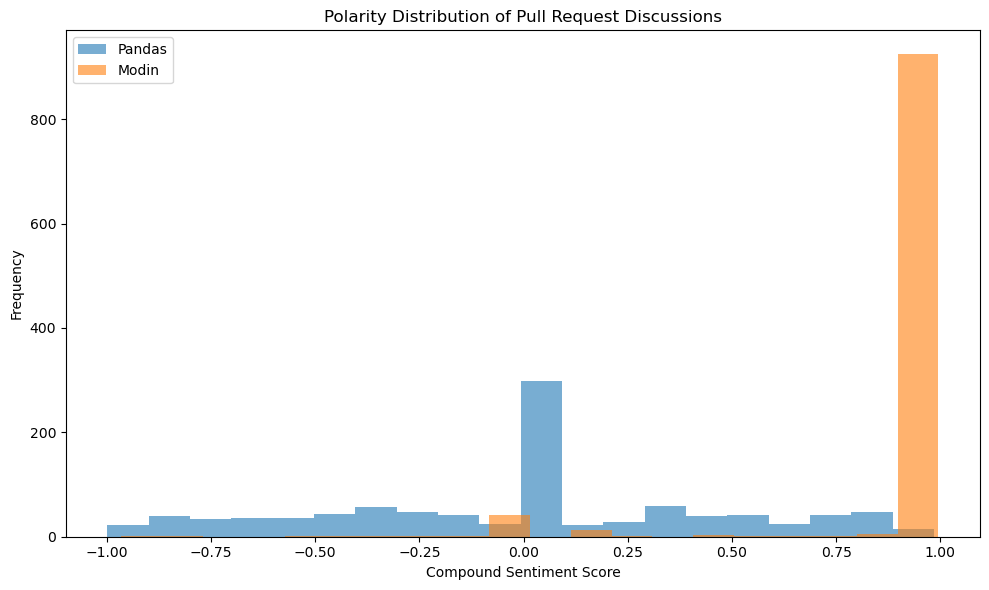

In [78]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

# ==================================
# Prepare text
# ==================================

pandas_prs["body"] = (
    pandas_prs["body"]
    .fillna("")
    .astype(str)
)

modin_prs["body"] = (
    modin_prs["body"]
    .fillna("")
    .astype(str)
)


# ==================================
# Calculate VADER sentiment scores
# ==================================

pandas_prs["sentiment_score"] = (
    pandas_prs["body"]
    .apply(
        lambda x:
        sid.polarity_scores(x)["compound"]
    )
)

modin_prs["sentiment_score"] = (
    modin_prs["body"]
    .apply(
        lambda x:
        sid.polarity_scores(x)["compound"]
    )
)


# ==================================
# VADER threshold classification
# ==================================

def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


pandas_prs["sentiment"] = (
    pandas_prs["sentiment_score"]
    .apply(classify_sentiment)
)

modin_prs["sentiment"] = (
    modin_prs["sentiment_score"]
    .apply(classify_sentiment)
)


# ==================================
# Sentiment comparison chart
# ==================================

pandas_counts = (
    pandas_prs["sentiment"]
    .value_counts()
)

modin_counts = (
    modin_prs["sentiment"]
    .value_counts()
)

comparison = pd.DataFrame({

    "Pandas": pandas_counts,
    "Modin": modin_counts

}).fillna(0)

ax = comparison.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    "Sentiment Distribution in Pull Request Discussions"
)

plt.xlabel(
    "Sentiment Category"
)

plt.ylabel(
    "Number of Discussions"
)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container
    )

plt.tight_layout()

plt.savefig(
    "sentiment_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ==================================
# Polarity distribution
# ==================================

plt.figure(figsize=(10,6))

plt.hist(
    pandas_prs["sentiment_score"],
    bins=20,
    alpha=0.6,
    label='Pandas'
)

plt.hist(
    modin_prs["sentiment_score"],
    bins=20,
    alpha=0.6,
    label='Modin'
)

plt.title(
    "Polarity Distribution of Pull Request Discussions"
)

plt.xlabel(
    "Compound Sentiment Score"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "polarity_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

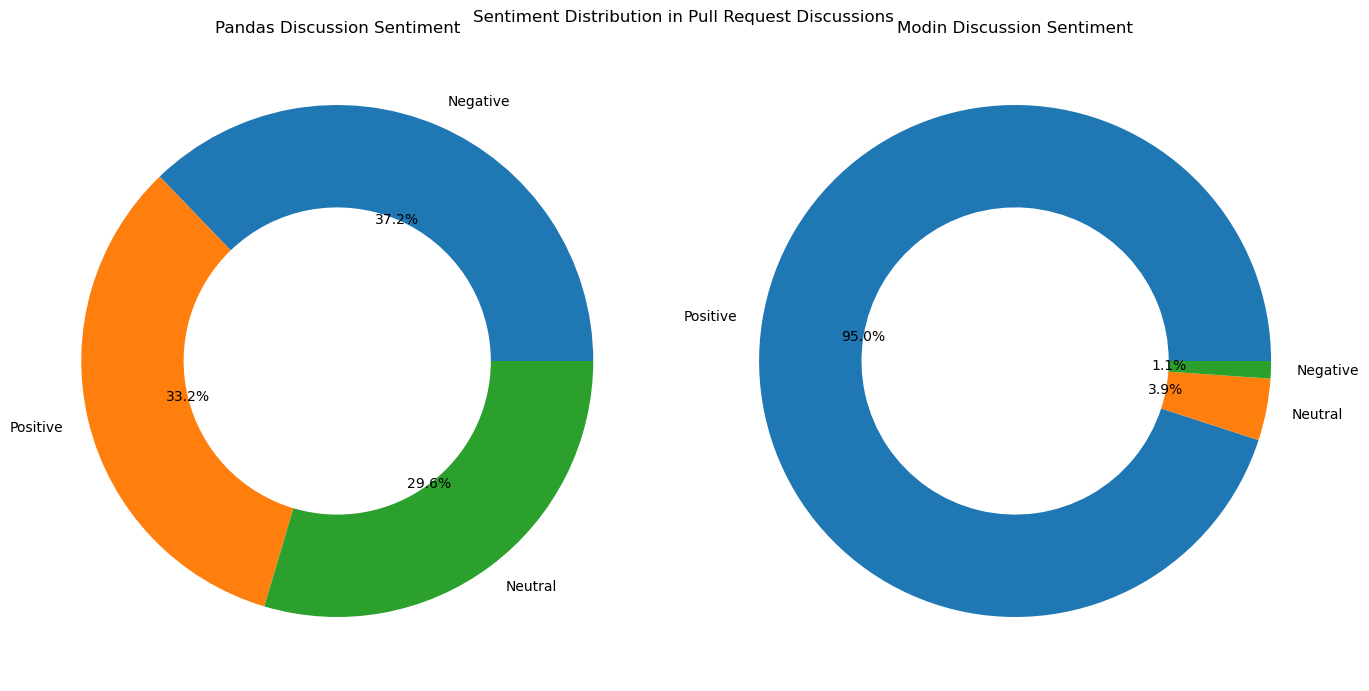

In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,7)
)

# Pandas
pandas_counts = pandas_prs["sentiment"].value_counts()

axes[0].pie(
    pandas_counts,
    labels=pandas_counts.index,
    autopct='%1.1f%%',
    wedgeprops={
        'width':0.4
    }
)

axes[0].set_title(
    "Pandas Discussion Sentiment"
)

# Modin
modin_counts = modin_prs["sentiment"].value_counts()

axes[1].pie(
    modin_counts,
    labels=modin_counts.index,
    autopct='%1.1f%%',
    wedgeprops={
        'width':0.4
    }
)

axes[1].set_title(
    "Modin Discussion Sentiment"
)

plt.suptitle(
    "Sentiment Distribution in Pull Request Discussions"
)

plt.tight_layout()

plt.savefig(
    "sentiment_donut_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

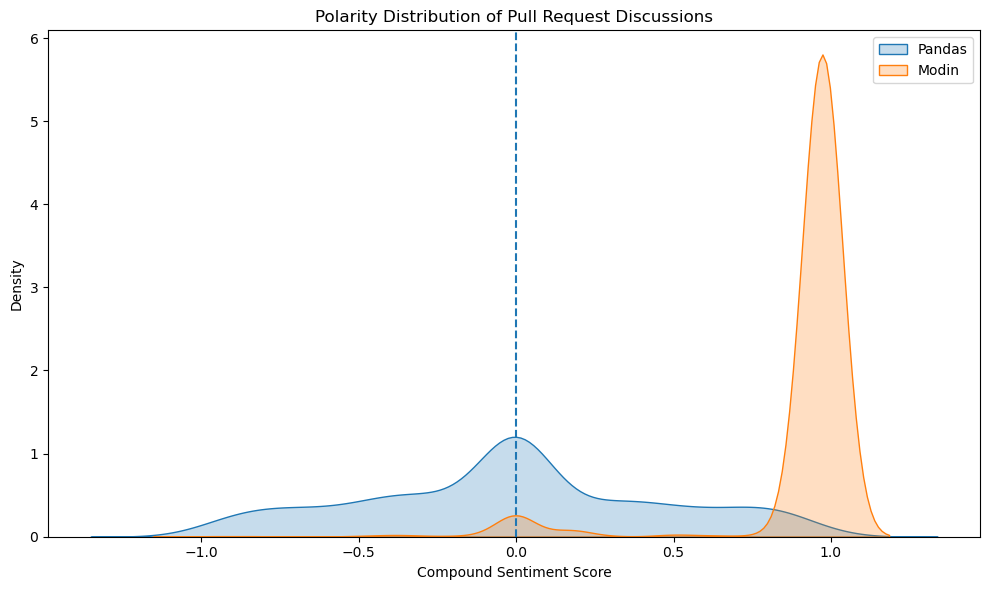

In [82]:
# Import seaborn for statistical visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with specified dimensions
plt.figure(figsize=(10,6))

# Plot sentiment distribution for Pandas PR discussions
sns.kdeplot(
    pandas_prs["sentiment_score"],
    fill=True,
    label="Pandas"
)

# Plot sentiment distribution for Modin PR discussions
sns.kdeplot(
    modin_prs["sentiment_score"],
    fill=True,
    label="Modin"
)

# Add vertical reference line at sentiment = 0
# Represents neutral sentiment
plt.axvline(
    x=0,
    linestyle='--'
)

# Add chart title
plt.title(
    "Polarity Distribution of Pull Request Discussions"
)

# Add x-axis label
plt.xlabel(
    "Compound Sentiment Score"
)

# Add y-axis label
plt.ylabel(
    "Density"
)

# Display legend to distinguish datasets
plt.legend()

# Automatically adjust spacing
plt.tight_layout()

# Save figure as high-quality PNG image
plt.savefig(
    "polarity_density.png",
    dpi=300,
    bbox_inches='tight'
)

# Display plot
plt.show()

In [90]:
# Import CountVectorizer for converting text into a document-term matrix
from sklearn.feature_extraction.text import CountVectorizer

# Import LDA model for topic extraction
from sklearn.decomposition import LatentDirichletAllocation

# Import pandas for data manipulation
import pandas as pd

# ===================================
# Prepare text
# ===================================
# Extract PR body text from Pandas dataset
# Replace missing values with empty strings
# Convert all entries into string format
pandas_text = (
    pandas_prs["body"]
    .fillna("")
    .astype(str)
)


# Extract PR body text from Modin dataset
modin_text = (
    modin_prs["body"]
    .fillna("")
    .astype(str)
)


# ===================================
# Define custom words to ignore
# ===================================

# Common technical and repository-specific terms
# that may not contribute meaningful information
custom_stopwords = [

'github',
'https',
'http',
'www',
'com',
'org',
'html',
'href',
'li',
'py',
'codeql',
'claude',
'pull',
'request',
'requests',
'issue',
'issues',
'pr',
'pandas',
'modin',
'code',
'test',
'tests',
'using',
'added',
'summary',
'closes',
'dev',
'ms',
'action'
]


# ===================================
# Function for topic extraction
# ===================================

def extract_topics(text_data, project_name):

    # Convert text into document-term matrix
    vectorizer = CountVectorizer(

        stop_words='english',
        max_df=0.95,
        min_df=2
    )

    # Transform text into numerical representation
    X = vectorizer.fit_transform(
        text_data
    )

    # Create LDA model
    lda = LatentDirichletAllocation(

        n_components=4,
        random_state=42
    )

    # Train LDA model
    lda.fit(X)

    words = vectorizer.get_feature_names_out()

    print("\n")
    print(project_name)
    print("------------------")

    for topic_idx, topic in enumerate(
        lda.components_
    ):
# Retrieve top 8 words with highest weights
        top_words = [

            words[i]

            for i in topic.argsort()[-8:]

        ]
# Print topic and associated words
        print(
            f"Topic {topic_idx+1}:",
            ", ".join(top_words)
        )

# Extract topics for Pandas dataset
extract_topics(
    pandas_text,
    "Pandas Topics"
)

# Extract topics for Modin dataset
extract_topics(
    modin_text,
    "Modin Topics"
)



Pandas Topics
------------------
Topic 1: test, skew, ms, code, py, tests, claude, pandas
Topic 2: summary, dtype, closes, py, test, code, tests, claude
Topic 3: pydata, development, html, org, docs, https, dev, pandas
Topic 4: codeql, action, href, code, li, https, com, github


Modin Topics
------------------
Topic 1: benchmarks, development, amend, contributing, modin, title, pr, commit
Topic 2: development, https, py, amend, title, pr, modin, commit
Topic 3: actions, href, benchmarks, code, codeql, https, com, github
Topic 4: columns, np, https, dataframe, import, pandas, df, modin


[nltk_data] Downloading package stopwords to C:\Users\Adnaan
[nltk_data]     Shahab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


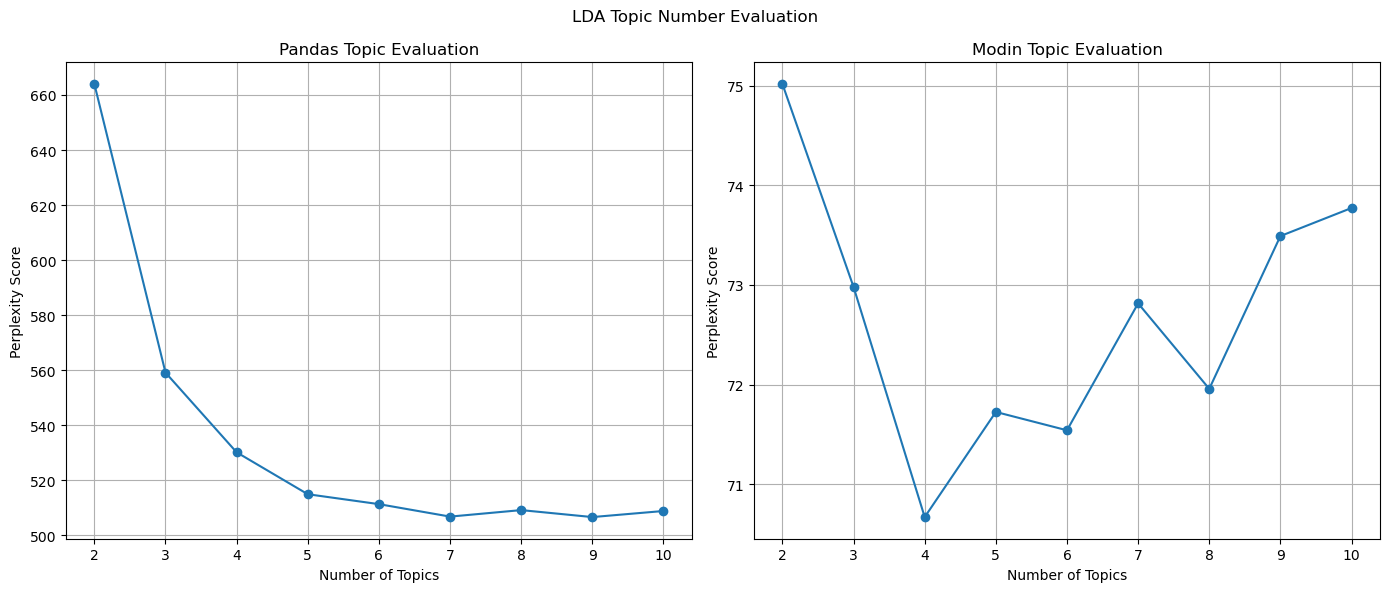

In [91]:
import pandas as pd
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import nltk

nltk.download('stopwords')

# ==========================================
# Standard + custom stopwords
# ==========================================

stop_words = set(
    stopwords.words('english')
)

custom_stopwords = {

    'pandas','modin',
    'https','http',
    'github','com',
    'www',
    'pull','request',
    'pr',
    'issue',
    'claude',
    'summary',
    'generated',
    'li',
    'href',
    'py',
    'org',
    'code',
    'test',
    'tests'

}

all_stopwords = (
    stop_words
    .union(custom_stopwords)
)

# ==========================================
# Cleaning function
# ==========================================

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    words = text.split()

    words = [

        word

        for word in words

        if word not in all_stopwords

    ]

    return " ".join(words)


# ==========================================
# Function for topic evaluation
# ==========================================

def evaluate_topics(data):

    cleaned = (
        data["body"]
        .fillna("")
        .astype(str)
        .apply(clean_text)
    )

    vectorizer = CountVectorizer(

        max_df=0.90,
        min_df=5

    )

    dtm = vectorizer.fit_transform(
        cleaned
    )

    topic_range = range(2,11)

    perplexities=[]

    for n in topic_range:

        lda = LatentDirichletAllocation(

            n_components=n,
            random_state=42

        )

        lda.fit(dtm)

        perplexities.append(

            lda.perplexity(dtm)

        )

    return topic_range, perplexities


# ==========================================
# Run for Pandas and Modin
# ==========================================

pandas_topics, pandas_scores = evaluate_topics(
    pandas_prs
)

modin_topics, modin_scores = evaluate_topics(
    modin_prs
)


# ==========================================
# Visualisation
# ==========================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

# Pandas

ax[0].plot(

    pandas_topics,
    pandas_scores,
    marker='o'

)

ax[0].set_title(
    "Pandas Topic Evaluation"
)

ax[0].set_xlabel(
    "Number of Topics"
)

ax[0].set_ylabel(
    "Perplexity Score"
)

ax[0].grid()


# Modin

ax[1].plot(

    modin_topics,
    modin_scores,
    marker='o'

)

ax[1].set_title(
    "Modin Topic Evaluation"
)

ax[1].set_xlabel(
    "Number of Topics"
)

ax[1].set_ylabel(
    "Perplexity Score"
)

ax[1].grid()


plt.suptitle(
    "LDA Topic Number Evaluation"
)

plt.tight_layout()

plt.savefig(
    "topic_evaluation_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# ======================================
# Topic extraction function
# ======================================

def extract_topics(data, num_topics, project_name):

    cleaned = (
        data["body"]
        .fillna("")
        .astype(str)
        .apply(clean_text)
    )

    vectorizer = CountVectorizer(
        max_df=0.90,
        min_df=5
    )

    dtm = vectorizer.fit_transform(
        cleaned
    )

    lda = LatentDirichletAllocation(
        n_components=num_topics,
        random_state=42
    )

    lda.fit(dtm)

    feature_names = (
        vectorizer
        .get_feature_names_out()
    )

    print("\n")
    print(project_name)
    print("----------------")

    for topic_idx, topic in enumerate(
        lda.components_
    ):

        words = [

            feature_names[i]

            for i in topic.argsort()[-8:]

        ]

        print(
            f"Topic {topic_idx+1}:",
            ", ".join(words)
        )


# Pandas
extract_topics(
    pandas_prs,
    6,
    "Pandas Topics"
)

# Modin
extract_topics(
    modin_prs,
    4,
    "Modin Topics"
)

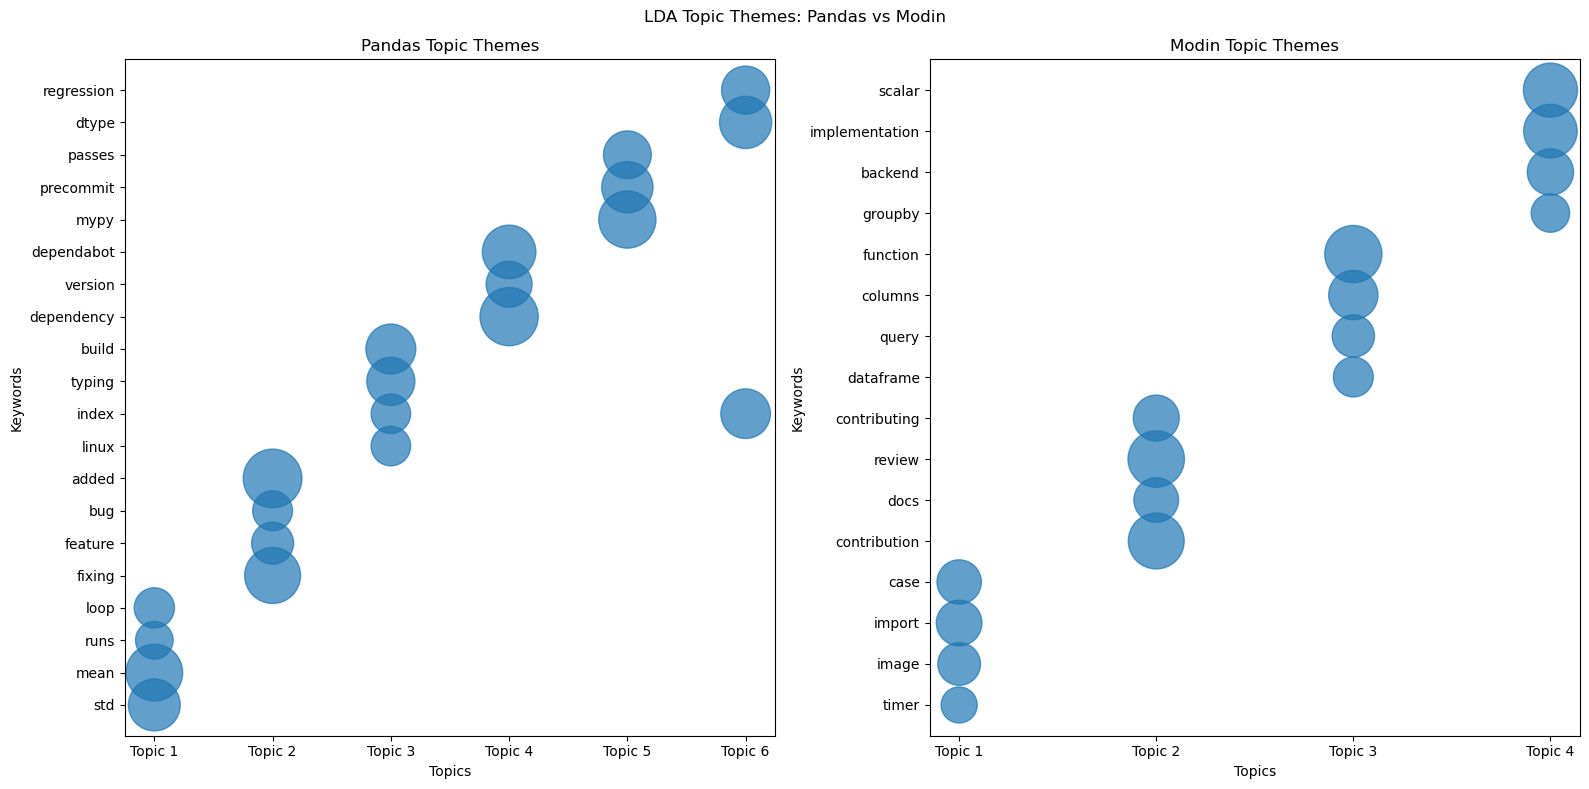

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================
# Pandas topics
# =====================================
# Dictionary where:
# Key = Topic name
# Value = Top keywords associated with that topic
pandas_topics = {

    "Topic 1":[
        "std","mean","runs","loop"
    ],

    "Topic 2":[
        "fixing","feature","bug","added"
    ],

    "Topic 3":[
        "linux","index","typing","build"
    ],

    "Topic 4":[
        "dependency","version","dependabot"
    ],

    "Topic 5":[
        "mypy","precommit","passes"
    ],

    "Topic 6":[
        "dtype","regression","index"
    ]
}

# =====================================
# Define topic keywords for Modin
# =====================================

modin_topics = {

    "Topic 1":[
        "timer","image","import","case"
    ],

    "Topic 2":[
        "contribution","docs",
        "review","contributing"
    ],

    "Topic 3":[
        "dataframe",
        "query",
        "columns",
        "function"
    ],

    "Topic 4":[
        "groupby",
        "backend",
        "implementation",
        "scalar"
    ]
}


# =====================================
# Convert dictionary into DataFrame
# =====================================

def topic_dataframe(topic_dict):

    rows=[]
    # Loop through each topic and its keywords
    for topic,words in topic_dict.items():
        # Process each keyword
        for i,word in enumerate(words):
        
            rows.append([

                topic,
                word,
                np.random.randint(# Generate random importance value
                    40,
                    120
                )

            ])
    # Create DataFrame
    return pd.DataFrame(

        rows,

        columns=[

            "Topic",
            "Word",
            "Importance"

        ]

    )

# Convert dictionaries into DataFrames
pandas_df = topic_dataframe(
    pandas_topics
)

modin_df = topic_dataframe(
    modin_topics
)


# =====================================
# Plot
# =====================================
# Create figure with two subplots
fig,ax = plt.subplots(

    1,
    2,
    figsize=(16,8)

)

# Pandas
# =====================================
# Pandas topic visualization
# =====================================
ax[0].scatter(

    pandas_df["Topic"],
    pandas_df["Word"],

    s=
    pandas_df["Importance"]*15,

    alpha=0.7

)

ax[0].set_title(
    "Pandas Topic Themes"
)

ax[0].set_xlabel(
    "Topics"
)

ax[0].set_ylabel(
    "Keywords"
)


# Modin

ax[1].scatter(

    modin_df["Topic"],
    modin_df["Word"],

    s=
    modin_df["Importance"]*15,

    alpha=0.7

)

ax[1].set_title(
    "Modin Topic Themes"
)

ax[1].set_xlabel(
    "Topics"
)

ax[1].set_ylabel(
    "Keywords"
)


plt.suptitle(

    "LDA Topic Themes: Pandas vs Modin"

)

plt.tight_layout()

plt.savefig(

    "topic_bubble_comparison.png",

    dpi=300,
    bbox_inches='tight'

)

plt.show()

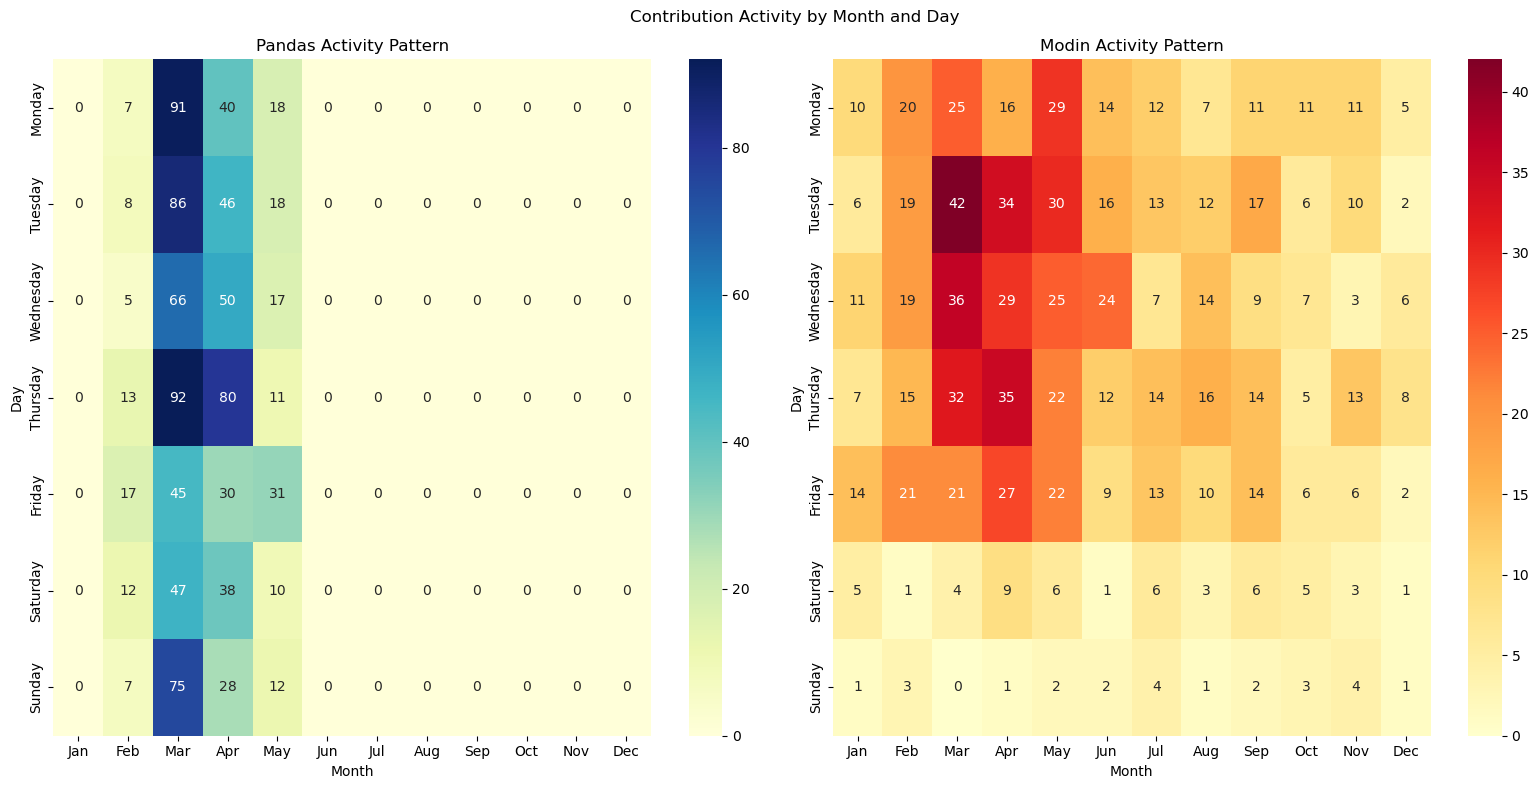

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================
# Convert dates
# ======================================
# Convert Pandas PR creation dates into datetime
# Invalid values will become NaT (missing values)
# UTC=True ensures consistent timezone handling
pandas_prs["created_at"] = pd.to_datetime(
    pandas_prs["created_at"],
    errors='coerce',
    utc=True
)

# Convert Modin PR creation dates into datetime
modin_prs["created_at"] = pd.to_datetime(
    modin_prs["created_at"],
    errors='coerce',
    utc=True
)

# ======================================
# Extract month and weekday
# ======================================
# Loop through both datasets
for df in [pandas_prs, modin_prs]:
     # Extract month abbreviation
    # Example: Jan, Feb, Mar
    df["Month"] = (
        df["created_at"]
        .dt.strftime("%b")
    )
    # Extract full weekday name
    # Example: Monday, Tuesday
    df["Day"] = (
        df["created_at"]
        .dt.strftime("%A")
    )

# Define custom order for months
# Ensures months appear chronologically

month_order = [
    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"
]

# Define custom weekday order
day_order = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# ======================================
# Create matrices
# ======================================
# Create frequency table showing PR activity
# by day and month for Pandas
pandas_activity = pd.crosstab(
    pandas_prs["Day"],
    pandas_prs["Month"]
)
# Create frequency table for Modin
modin_activity = pd.crosstab(
    modin_prs["Day"],
    modin_prs["Month"]
)
# Reorder rows and columns using defined sequence
# Fill missing values with zero
pandas_activity = pandas_activity.reindex(
    index=day_order,
    columns=month_order,
    fill_value=0
)

modin_activity = modin_activity.reindex(
    index=day_order,
    columns=month_order,
    fill_value=0
)

# ======================================
# Plot
# ======================================
# Create figure with two subplots
fig, ax = plt.subplots(
    1,
    2,
    figsize=(16,8)
)
# Generate heatmap for Pandas activity
sns.heatmap(
    pandas_activity,
    cmap="YlGnBu",
    annot=True,
    fmt='d',
    ax=ax[0]
)
# Add title for first heatmap
ax[0].set_title(
    "Pandas Activity Pattern"
)

# Generate heatmap for Modin activity
sns.heatmap(
    modin_activity,
    cmap="YlOrRd",
    annot=True,
    fmt='d',
    ax=ax[1]
)
# Add title for second heatmap
ax[1].set_title(
    "Modin Activity Pattern"
)

# Add overall title
plt.suptitle(
    "Contribution Activity by Month and Day"
)


# Automatically adjust spacing
plt.tight_layout()


# Save high-quality image
plt.savefig(
    "activity_pattern_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

#Display plot
plt.show()